In [1]:
from google.colab import drive
drive.mount('/content/drive')

# copying and unzipping model
!cp /content/drive/MyDrive/Medical_AI_Project/phi3_doctor_openvino_int8.zip .
!unzip -q -o phi3_doctor_openvino_int8.zip

Mounted at /content/drive


In [2]:
# installing dependencies
!pip install optimum[openvino] transformers matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 658.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.9/371.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 40.0 MB/s eta 0:00:00
  Attempting uninstall: pydot
    Found exi

In [3]:
import time
from optimum.intel import OVModelForCausalLM
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
model_dir = "phi3_doctor_openvino_int8"

# loading Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = OVModelForCausalLM.from_pretrained(model_dir)

# store the data from the next cells here to plot later
test_labels = []
tokens_per_second = []

# Helper function to test, print, and time a question
def ask_and_time(prompt, label):
    print(f"User: {prompt}\n")

    formatted_prompt = f"<|user|>\n{prompt}<|end|>\n<|assistant|>\n"
    inputs = tokenizer(formatted_prompt, return_tensors="pt")

    start_time = time.time()
    outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.3, do_sample=True)
    end_time = time.time()

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"AI: {response}\n")

    # Calculate stats
    gen_time = end_time - start_time
    num_tokens = outputs.shape[1] - inputs['input_ids'].shape[1]
    speed = num_tokens / gen_time

    print(f"Stats: Took {gen_time:.2f} seconds | {num_tokens} tokens | {speed:.2f} tokens/sec")
    print("-" * 60)

    # Save data for plotting
    test_labels.append(label)
    tokens_per_second.append(speed)

In [5]:
ask_and_time("I have a migraine headache.", "Q1 (Short)")

User: I have a migraine headache.

AI: Hi, Welcome to Chat Doctor. Migraine is a common cause of headache. It is characterized by throbbing pain, sensitivity to light and sound, nausea and vomiting. It is more common in females. It is often associated with aura. Aura is a collection of symptoms like visual disturbances, sensory disturbances, speech disturbances. It is more common in women. It is due to a disturbance in the brain. It is not due to any structural abnormality in the brain. It is more common in females. It is more common in young adults. It is more common in winter. It is more common in females. It is more common in

Stats: Took 125.67 seconds | 150 tokens | 1.19 tokens/sec
------------------------------------------------------------


In [6]:
ask_and_time("What is the best way to treat a minor burn from cooking?", "Q2 (Medium)")

User: What is the best way to treat a minor burn from cooking?

AI: Hi, Thanks for asking question on Chat Doctor. I have read your question in detail and I understand your concern. You have minor burn from cooking. I will suggest you following things for better recovery.1. Cool the burned area with cold water.2. Apply antibiotic ointment like Neosporin.3. Apply bandage over it.4. Take painkiller like ibuprofen. Hope this will help you. Wishing you good health.

Stats: Took 82.83 seconds | 105 tokens | 1.27 tokens/sec
------------------------------------------------------------


In [7]:
ask_and_time("I feel tired all the time, I'm always thirsty, and I need to pee a lot. What could this be?", "Q3 (Long)")

User: I feel tired all the time, I'm always thirsty, and I need to pee a lot. What could this be?

AI: Hi, Thanks for asking question on Chat Doctor. I have read your question in detail and I understand your concern. You have symptoms of diabetes mellitus. You should get your blood sugar level checked. If it is high than you have diabetes. You should start treatment for diabetes. You should also get urine test done to rule out urinary tract infection. You should also get your blood pressure checked. You should also get your lipid profile checked. You should also get your kidney function tests done. You should also get your thyroid function tests done. You should also get your chest x-ray done to rule out lung infection. You should also get your ECG done

Stats: Took 114.49 seconds | 150 tokens | 1.31 tokens/sec
------------------------------------------------------------


In [8]:
ask_and_time("I am a 55-year-old male experiencing crushing chest pain that radiates to my left jaw and shoulder. I'm also sweating profusely. What should I do?", "Q4 (Emergency)")

User: I am a 55-year-old male experiencing crushing chest pain that radiates to my left jaw and shoulder. I'm also sweating profusely. What should I do?

AI: Hello, I understand your concern. You have not mentioned your blood pressure, pulse, respiratory rate, temperature, and oxygen saturation. I would like to know if you have any history of heart disease, diabetes, or hypertension. I would recommend you to go to the emergency room immediately. You may have a heart attack. I would recommend you to do an electrocardiogram and a blood test to measure your cardiac enzymes. You may need to take medications to relieve your symptoms and prevent further damage to your heart. I hope this information has been helpful. Please feel free to ask if you have any further questions.

Stats: Took 112.66 seconds | 141 tokens | 1.25 tokens/sec
------------------------------------------------------------


In [9]:
ask_and_time("My latest blood test showed an HbA1c of 7.2%. What does this mean, and what lifestyle modifications should I consider?", "Q5 (Lab Test)")

User: My latest blood test showed an HbA1c of 7.2%. What does this mean, and what lifestyle modifications should I consider?

AI: Hi, Welcome to Chat Doctor. I have gone through your query and understand your concern. HbA1c is a measure of the average blood glucose level over the last 3 months. It is used to diagnose diabetes and to monitor the treatment of diabetes. The normal level is below 5.7%. A level between 5.7% and 6.4% is considered prediabetes. A level of 6.5% or higher on two separate tests indicates diabetes. So, your level of 7.2% indicates that you have diabetes. You should take the following measures to control it. 1. Diet control. Eat a diet

Stats: Took 114.97 seconds | 150 tokens | 1.30 tokens/sec
------------------------------------------------------------


In [10]:
ask_and_time("I take Lisinopril for high blood pressure. I just caught a cold and want to take an over-the-counter decongestant containing pseudoephedrine. Is this safe?", "Q6 (Pharm)")

User: I take Lisinopril for high blood pressure. I just caught a cold and want to take an over-the-counter decongestant containing pseudoephedrine. Is this safe?

AI: Hello, I am Chat Doctor.  I understand your concern. You can take pseudoephedrine. It is safe to take with Lisinopril. However, it can cause increase in blood pressure. So, you should monitor your blood pressure regularly. You can also take antihistamine like cetirizine or levocetirizine. It will not affect your blood pressure. It will also help you to relieve cold symptoms. Hope I have answered your query. Let me know if I can assist you further.

Stats: Took 90.66 seconds | 114 tokens | 1.26 tokens/sec
------------------------------------------------------------


In [11]:
ask_and_time("My 4-year-old child has had a fever, a harsh barking cough, and seems to have trouble catching his breath, especially at night. What could be causing this?", "Q7 (Pediatrics)")

User: My 4-year-old child has had a fever, a harsh barking cough, and seems to have trouble catching his breath, especially at night. What could be causing this?

AI: Hi, Thank you for your question. I am sorry to hear that your child is not feeling well. The symptoms you describe are suggestive of a viral upper respiratory tract infection. This is the most common cause of fever and cough in children. It is usually self-limiting and requires only symptomatic treatment. I recommend giving him plenty of fluids, and you can give him paracetamol for fever. You can also give him cough syrup. I hope this helps. Please feel free to ask any further questions.

Stats: Took 94.34 seconds | 119 tokens | 1.26 tokens/sec
------------------------------------------------------------


In [12]:
ask_and_time("I noticed a sudden drooping on the right side of my face and can't close my right eye. However, I can still move my right arm and leg perfectly fine. What might be happening?", "Q8 (Neuro)")

User: I noticed a sudden drooping on the right side of my face and can't close my right eye. However, I can still move my right arm and leg perfectly fine. What might be happening?

AI: Hello, Thank you for your question. I am sorry to hear about your problem. The symptoms you describe are suggestive of a stroke. A stroke is a sudden loss of blood supply to a part of the brain. It can cause sudden weakness or numbness of the face, arm, or leg, especially on one side of the body, difficulty speaking or understanding speech, and difficulty seeing in one or both eyes. The symptoms of a stroke are sudden and severe. It is very important to seek immediate medical attention if you suspect a stroke. I hope this information has been helpful. Please let me know if you have any further questions.

Stats: Took 112.13 seconds | 133 tokens | 1.19 tokens/sec
------------------------------------------------------------


In [13]:
ask_and_time("I've been feeling incredibly overwhelmed lately. I can't sleep, I've lost my appetite, and sometimes I feel like things would be easier if I just wasn't here anymore. Who can I talk to?", "Q9 (Mental Health)")

User: I've been feeling incredibly overwhelmed lately. I can't sleep, I've lost my appetite, and sometimes I feel like things would be easier if I just wasn't here anymore. Who can I talk to?

AI: Hello, Welcome to Chat Doctor. I have read your query and understand your concern. You seem to be suffering from depression. You need to consult a psychiatrist and get evaluated. You may need to take some antidepressant medication. You may also need to undergo counseling sessions. You need to avoid stress and anxiety. You need to be positive and hopeful. You need to be happy and cheerful. You need to be active and productive. You need to be healthy and fit. You need to be confident and self-assured. You need to be calm and relaxed. You need to be strong and resilient. You need to be happy and satisfied. You need to

Stats: Took 122.02 seconds | 150 tokens | 1.23 tokens/sec
------------------------------------------------------------


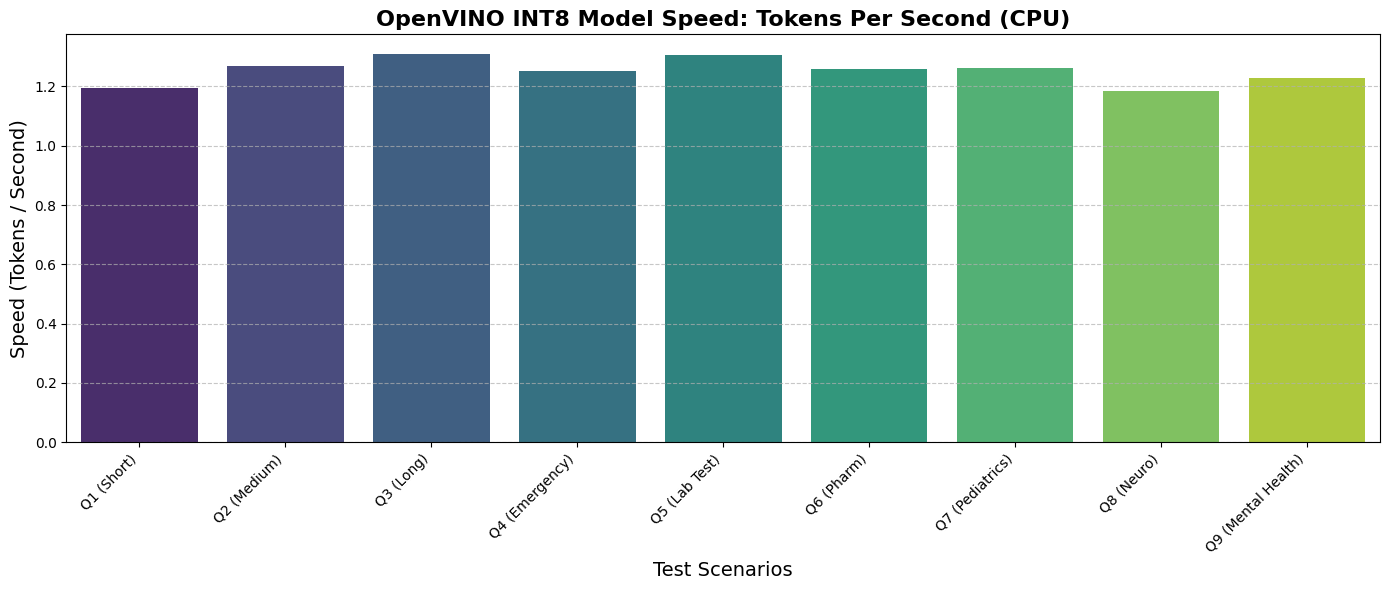

Average Speed across 9 complex prompts: 1.25 tokens/sec


In [14]:
plt.figure(figsize=(14, 6))
sns.barplot(x=test_labels, y=tokens_per_second, palette="viridis", hue=test_labels, legend=False)
plt.title("OpenVINO INT8 Model Speed: Tokens Per Second (CPU)", fontsize=16, fontweight="bold")
plt.xlabel("Test Scenarios", fontsize=14)
plt.ylabel("Speed (Tokens / Second)", fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("inference_speed.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Average Speed across 9 complex prompts: {sum(tokens_per_second)/len(tokens_per_second):.2f} tokens/sec")

In [15]:
# Upload plot to drive
!cp inference_speed.png /content/drive/MyDrive/Medical_AI_Project/